Loading CIFAR-10 dataset...


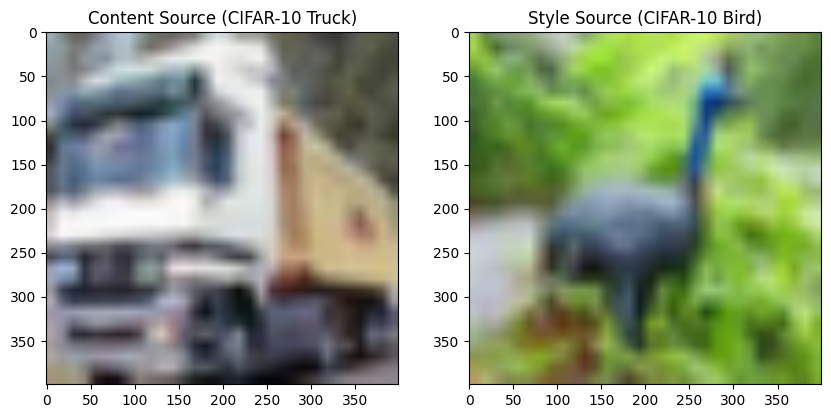

In [7]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import vgg19
from tqdm.notebook import tqdm

# Helper: Load and preprocess image tensors
def load_and_process_img(img_tensor):
    img = tf.image.convert_image_dtype(img_tensor, tf.float32)
    img = tf.image.resize(img, (400, 400)) # Resize for better VGG feature extraction
    return img[tf.newaxis, :]

# --- Load CIFAR-10 (Always works in Colab) ---
print("Loading CIFAR-10 dataset...")
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

# Content: Pick a 'Truck' (Index 1)
content_image = load_and_process_img(x_train[1])

# Style: Pick a 'Bird' (Index 6) or 'Frog' (Index 0) for interesting textures
style_image = load_and_process_img(x_train[6])

# Visualize the source images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(content_image[0]); plt.title('Content Source (CIFAR-10 Truck)')
plt.subplot(1, 2, 2); plt.imshow(style_image[0]); plt.title('Style Source (CIFAR-10 Bird)')
plt.show()

In [8]:
# Load Pretrained VGG19 (weights frozen)
vgg = vgg19.VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

# Layers for Content and Style
content_layers = ['block5_conv2']
style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']

def get_vgg_layers(layer_names):
    outputs = [vgg.get_layer(name).output for name in layer_names]
    return tf.keras.Model([vgg.input], outputs)

def gram_matrix(input_tensor):
    """Measures correlations between filters to capture texture."""
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
    return result / num_locations

class StyleContentModel(tf.keras.models.Model):
    def __init__(self, style_layers, content_layers):
        super(StyleContentModel, self).__init__()
        self.vgg = get_vgg_layers(style_layers + content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)

    def call(self, inputs):
        # VGG preprocessing (0-255 range)
        inputs = inputs * 255.0
        preprocessed = vgg19.preprocess_input(inputs)
        outputs = self.vgg(preprocessed)
        style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                          outputs[self.num_style_layers:])
        style_outputs = [gram_matrix(s) for s in style_outputs]
        return {'content': content_outputs, 'style': style_outputs}

extractor = StyleContentModel(style_layers, content_layers)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
# Extract target features from our source images
style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']

# Create the 'Variable' image that we will actually modify
# We start with the content image as a base
image = tf.Variable(content_image)

optimizer = tf.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)

@tf.function()
def train_step(image, style_weight=1e-2, content_weight=1e4):
    with tf.GradientTape() as tape:
        outputs = extractor(image)
        # 1. Style Loss
        s_loss = tf.add_n([tf.reduce_mean((outputs['style'][i] - style_targets[i])**2)
                           for i in range(len(style_layers))])
        s_loss *= style_weight / len(style_layers)
        # 2. Content Loss
        c_loss = tf.add_n([tf.reduce_mean((outputs['content'][i] - content_targets[i])**2)
                           for i in range(len(content_layers))])
        c_loss *= content_weight / len(content_layers)

        total_loss = s_loss + c_loss

    grad = tape.gradient(total_loss, image)
    optimizer.apply_gradients([(grad, image)])
    # Ensure pixels stay in valid [0, 1] range
    image.assign(tf.clip_by_value(image, 0.0, 1.0))

Optimizing image... please wait.


Epoch 1/50:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/100 [00:00<?, ?it/s]

...

Epoch 46/50:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 47/50:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 48/50:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 49/50:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 50/50:   0%|          | 0/100 [00:00<?, ?it/s]

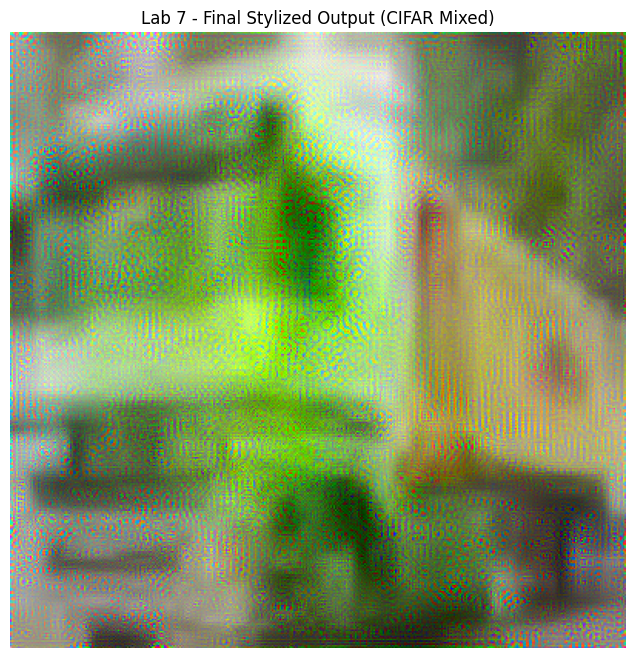

In [11]:
epochs = 50
steps_per_epoch = 100

print("Optimizing image... please wait.")
for n in range(epochs):
    for m in tqdm(range(steps_per_epoch), desc=f"Epoch {n+1}/{epochs}"):
        train_step(image)

# Final Result
plt.figure(figsize=(8, 8))
plt.imshow(image.read_value()[0])
plt.axis('off')
plt.title('Lab 7 - Final Stylized Output (CIFAR Mixed)')
plt.show()